# Modelo 10 clases


In [17]:
import tensorflow as tf
import os

In [18]:
Ruta = r"C:/Users/gerar/Desktop/Analizador-de-Textura-main/Modelo2026/10clases"
Imagenes = (128, 128)
Batch = 32

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    Ruta,
    validation_split=0.2,   # Reservamos el 20% para pruebas
    subset="training",
    seed=123,               # Semilla para que el orden sea reproducible
    image_size=Imagenes,
    batch_size=Batch
)

Found 1168 files belonging to 10 classes.
Using 935 files for training.


In [20]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    Ruta,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=Imagenes,
    batch_size=Batch
)

Found 1168 files belonging to 10 classes.
Using 233 files for validation.


In [21]:
print(f"Clases encontradas: {train_ds.class_names}")

Clases encontradas: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline']


In [22]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.1), # Vital para texturas
])

# Úsalo al principio del modelo
# model.add(data_augmentation) ...

In [23]:
from tensorflow.keras import layers, models, applications

# 1. Cargamos una red pre-entrenada (MobileNetV2) sin la parte final
base_model = applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False, 
    weights='imagenet'
)

# 2. "Congelamos" la red base para no destruir lo que ya sabe
base_model.trainable = False

# 3. Creamos tu modelo usando esa base
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    # Aumento de datos suave
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    
    # La base pre-entrenada
    base_model,
    
    # Convertimos los mapas de características en un vector
    layers.GlobalAveragePooling2D(),
    
    # Capas de clasificación final
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 4. Compilación con una tasa de aprendizaje estándar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
# Entrenamos por 20 épocas para ver cómo reacciona
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80
)

Epoch 1/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.6043 - loss: 1.1255 - val_accuracy: 0.3777 - val_loss: 2.0585
Epoch 2/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.5914 - loss: 1.1249 - val_accuracy: 0.4249 - val_loss: 2.0411
Epoch 3/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.6075 - loss: 1.0900 - val_accuracy: 0.3948 - val_loss: 2.1093
Epoch 4/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.6043 - loss: 1.0617 - val_accuracy: 0.4077 - val_loss: 2.0796
Epoch 5/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.6246 - loss: 1.0564 - val_accuracy: 0.3906 - val_loss: 2.1513
Epoch 6/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.6128 - loss: 1.0604 - val_accuracy: 0.4034 - val_loss: 2.1086
Epoch 7/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.6182 - loss: 1.0730 - val_accuracy: 0.3948 - val_loss: 2.1019
Epoch 8/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.6364 - loss: 1.0390 - val_accuracy: 0.

Probando imágenes en: C:/Users/gerar/Desktop/Analizador-de-Textura-main/Modelo2026/10clasesPrueba



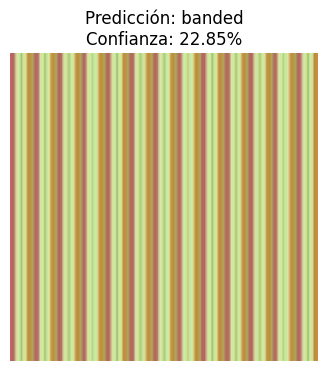

Archivo: banded_0002.jpg -> Resultado: banded (22.85%)


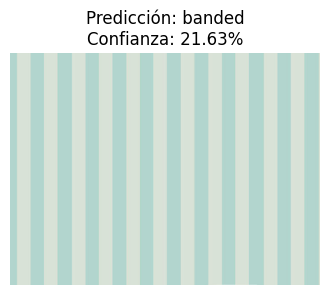

Archivo: banded_0046.jpg -> Resultado: banded (21.63%)


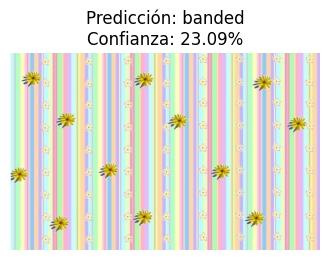

Archivo: banded_0060.jpg -> Resultado: banded (23.09%)


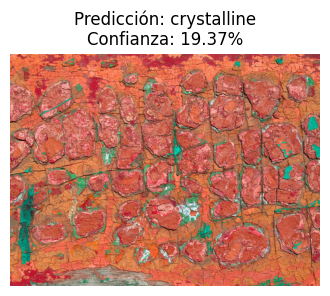

Archivo: blotchy_0003.jpg -> Resultado: crystalline (19.37%)


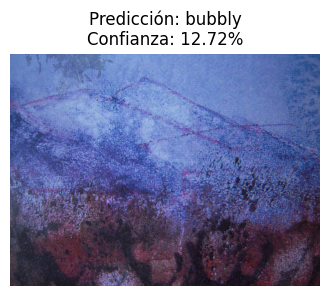

Archivo: blotchy_0025.jpg -> Resultado: bubbly (12.72%)


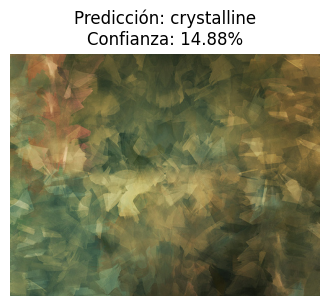

Archivo: blotchy_0036.jpg -> Resultado: crystalline (14.88%)


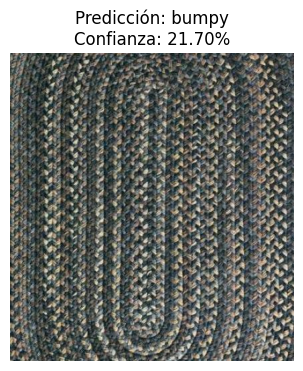

Archivo: braided_0006.jpg -> Resultado: bumpy (21.70%)


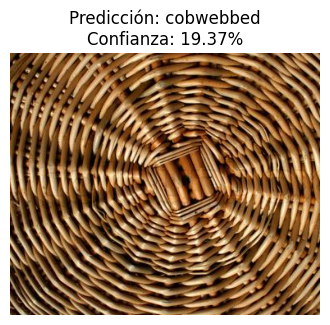

Archivo: braided_0078.jpg -> Resultado: cobwebbed (19.37%)


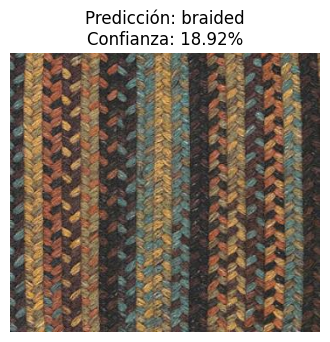

Archivo: braided_0081.jpg -> Resultado: braided (18.92%)


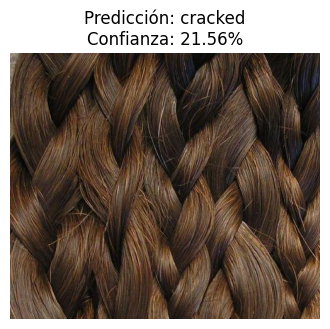

Archivo: braided_0099.jpg -> Resultado: cracked (21.56%)


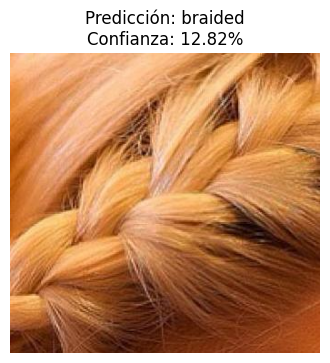

Archivo: braided_0115.jpg -> Resultado: braided (12.82%)


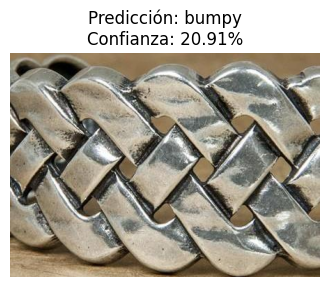

Archivo: braided_0118.jpg -> Resultado: bumpy (20.91%)


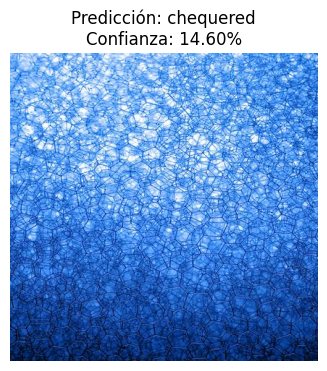

Archivo: bubbly_0042.jpg -> Resultado: chequered (14.60%)


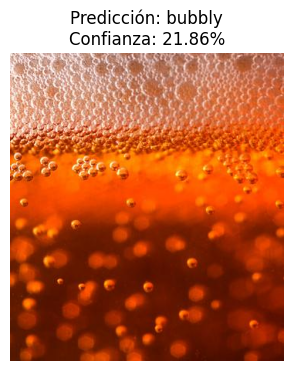

Archivo: bubbly_0063.jpg -> Resultado: bubbly (21.86%)


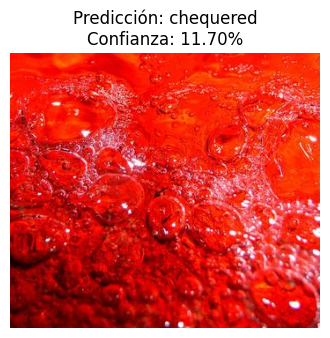

Archivo: bubbly_0087.jpg -> Resultado: chequered (11.70%)


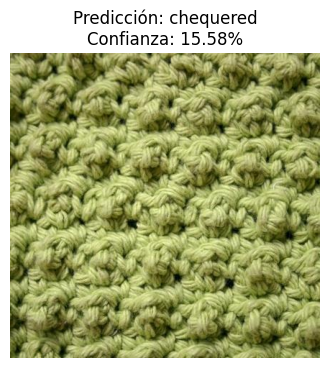

Archivo: bumpy_0021.jpg -> Resultado: chequered (15.58%)


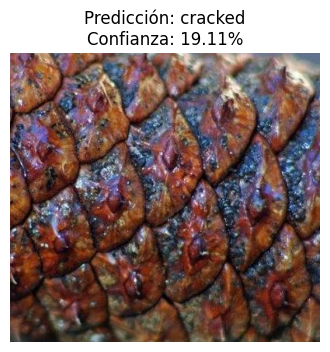

Archivo: bumpy_0110.jpg -> Resultado: cracked (19.11%)


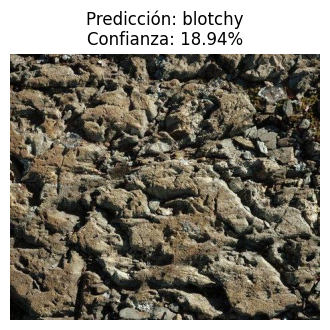

Archivo: bumpy_0119.jpg -> Resultado: blotchy (18.94%)


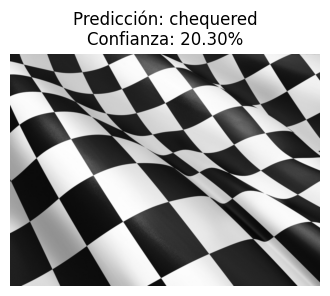

Archivo: chequered_0069.jpg -> Resultado: chequered (20.30%)


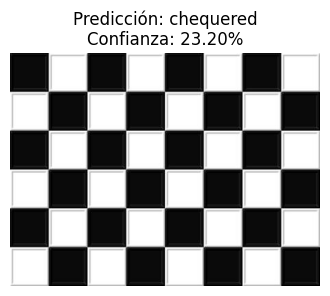

Archivo: chequered_0109.jpg -> Resultado: chequered (23.20%)


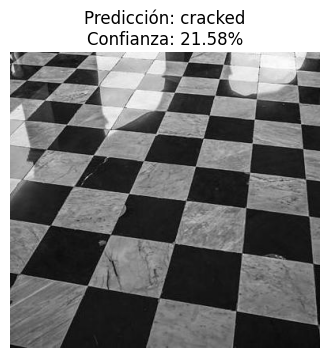

Archivo: chequered_0112.jpg -> Resultado: cracked (21.58%)


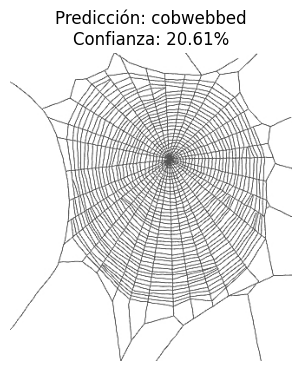

Archivo: cobwebbed_0053.jpg -> Resultado: cobwebbed (20.61%)


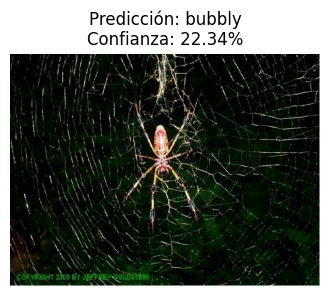

Archivo: cobwebbed_0070.jpg -> Resultado: bubbly (22.34%)


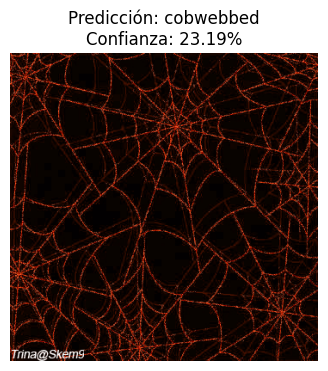

Archivo: cobwebbed_0071.jpg -> Resultado: cobwebbed (23.19%)


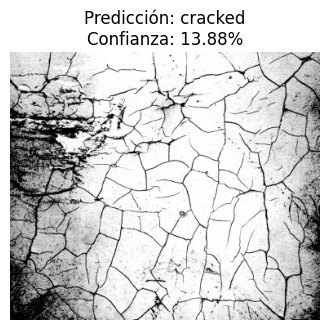

Archivo: cracked_0057.jpg -> Resultado: cracked (13.88%)


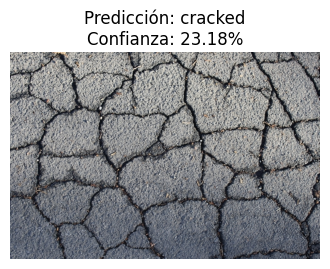

Archivo: cracked_0066.jpg -> Resultado: cracked (23.18%)


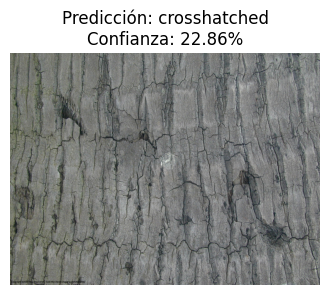

Archivo: cracked_0073.jpg -> Resultado: crosshatched (22.86%)


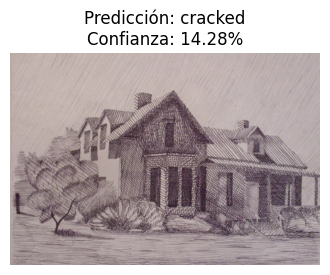

Archivo: crosshatched_0057.jpg -> Resultado: cracked (14.28%)


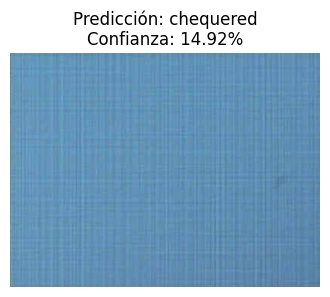

Archivo: crosshatched_0058.jpg -> Resultado: chequered (14.92%)


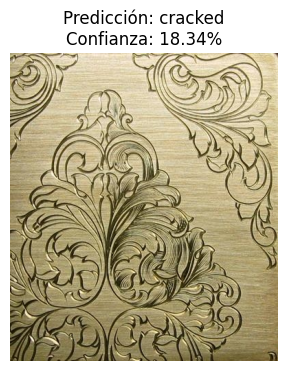

Archivo: crosshatched_0072.jpg -> Resultado: cracked (18.34%)


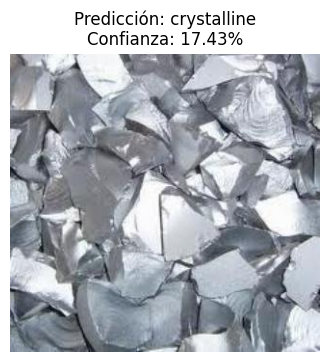

Archivo: crystalline_0057.jpg -> Resultado: crystalline (17.43%)


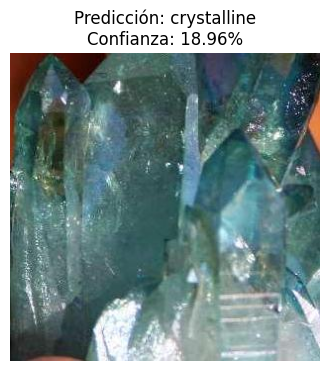

Archivo: crystalline_0120.jpg -> Resultado: crystalline (18.96%)


In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os


Ruta_Pruebas = r"C:/Users/gerar/Desktop/Analizador-de-Textura-main/Modelo2026/10clasesPrueba"
Imagenes_Size = (128, 128)

nombres_clases = train_ds.class_names 

def predecir_y_mostrar(ruta_imagen):
    # Cargar imagen para el modelo 
    img_modelo = image.load_img(ruta_imagen, target_size=Imagenes_Size)
    img_array = image.img_to_array(img_modelo)
    img_array = tf.expand_dims(img_array, 0) 

    # Predicción
    predicciones = model.predict(img_array, verbose=0)
    # Aplicamos softmax para obtener probabilidades 
    score = tf.nn.softmax(predicciones[0])
    
    clase_predicha = nombres_clases[np.argmax(score)]
    confianza = 100 * np.max(score)

    # Visualización 
    img_display = image.load_img(ruta_imagen) 
    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(f"Predicción: {clase_predicha}\nConfianza: {confianza:.2f}%")
    plt.axis('off')
    plt.show()

    return clase_predicha, confianza


print(f"Probando imágenes en: {Ruta_Pruebas}\n")


archivos = [f for f in os.listdir(Ruta_Pruebas) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not archivos:
    print("No se encontraron imágenes en la carpeta especificada.")
else:
    for archivo in archivos:
        ruta_completa = os.path.join(Ruta_Pruebas, archivo)
        clase, conf = predecir_y_mostrar(ruta_completa)
        print(f"Archivo: {archivo} -> Resultado: {clase} ({conf:.2f}%)")


Calculando predicciones para la matriz de confusión...


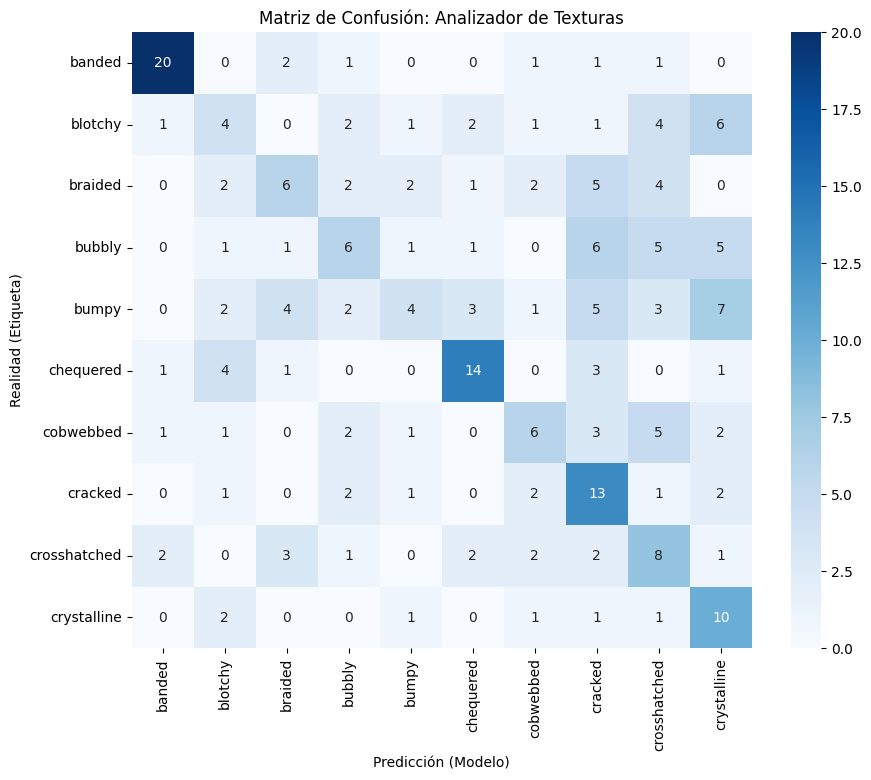


Reporte de Clasificación:
              precision    recall  f1-score   support

      banded       0.80      0.77      0.78        26
     blotchy       0.24      0.18      0.21        22
     braided       0.35      0.25      0.29        24
      bubbly       0.33      0.23      0.27        26
       bumpy       0.36      0.13      0.19        31
   chequered       0.61      0.58      0.60        24
   cobwebbed       0.38      0.29      0.32        21
     cracked       0.33      0.59      0.42        22
crosshatched       0.25      0.38      0.30        21
 crystalline       0.29      0.62      0.40        16

    accuracy                           0.39       233
   macro avg       0.39      0.40      0.38       233
weighted avg       0.40      0.39      0.38       233



In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener etiquetas reales y predicciones
y_true = []
y_pred = []

print("Calculando predicciones para la matriz de confusión...")

# Recorremos el dataset de validación
for imagenes, etiquetas in val_ds:
    preds = model.predict(imagenes, verbose=0)
    y_true.extend(etiquetas.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
nombres_clases = train_ds.class_names

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Etiqueta)')
plt.title('Matriz de Confusión: Analizador de Texturas')
plt.show()

# 4. Mostrar reporte de métricas detallado
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=nombres_clases))